In [1]:
import numpy as np
print(np.__version__)


1.26.4


In [2]:
pip install "numpy==1.26.4" --force-reinstall


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Optional: Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
# Replace 'ad_data.csv' with your file name or path
df = pd.read_csv(r"C:\Users\lavan\OneDrive\Desktop\Ad spend optimization\ad_table.csv")

# Display first few rows
print("📊 Data Preview:")
print(df.head())

# Check for null values
print("\n🧹 Missing Values:")
print(df.isnull().sum())


C:\Users\lavan\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


📊 Data Preview:
         date  shown  clicked  converted  avg_cost_per_click  total_revenue  \
0  2015-10-01  65877     2339         43                0.90         641.62   
1  2015-10-02  65100     2498         38                0.94         756.37   
2  2015-10-03  70658     2313         49                0.86         970.90   
3  2015-10-04  69809     2833         51                1.01         907.39   
4  2015-10-05  68186     2696         41                1.00         879.45   

           ad  
0  ad_group_1  
1  ad_group_1  
2  ad_group_1  
3  ad_group_1  
4  ad_group_1  

🧹 Missing Values:
date                  0
shown                 0
clicked               0
converted             0
avg_cost_per_click    0
total_revenue         0
ad                    0
dtype: int64



🔍 Missing Values:
shown                 0
clicked               0
converted             0
avg_cost_per_click    0
total_revenue         0
ad                    0
year                  0
month                 0
day                   0
dtype: int64

✅ Columns used for correlation:
['shown', 'clicked', 'converted', 'avg_cost_per_click', 'total_revenue', 'ad', 'year', 'month', 'day']


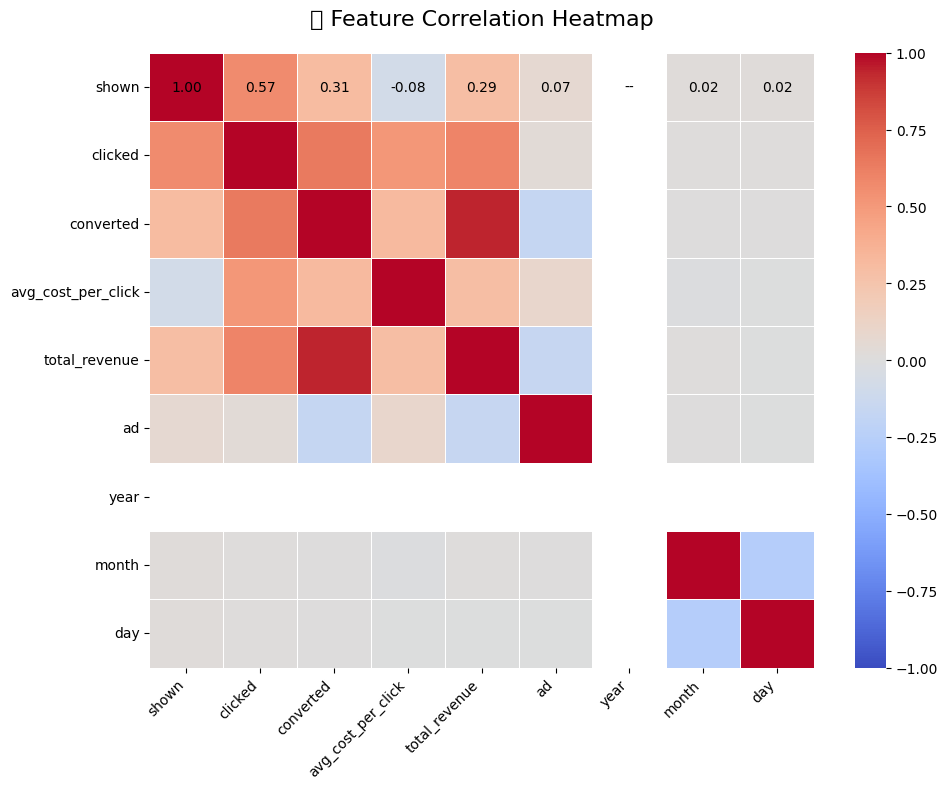

In [4]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# --- Load your dataset ---
df = pd.read_csv(r"C:\Users\lavan\OneDrive\Desktop\Ad spend optimization\ad_table.csv")

# --- Convert 'date' column to datetime ---
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- Extract year, month, and day ---
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# --- Encode 'ad' column (categorical to numeric) ---
if df['ad'].dtype == 'object':
    le = LabelEncoder()
    df['ad'] = le.fit_transform(df['ad'])

# --- Drop 'date' column (non-numeric) ---
df = df.drop(columns=['date'])

# --- Check missing values ---
print("\n🔍 Missing Values:")
print(df.isnull().sum())

# --- Force convert all to numeric just in case ---
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Drop completely empty columns (if any) ---
df = df.dropna(axis=1, how='all')

# --- Confirm numeric columns used ---
print("\n✅ Columns used for correlation:")
print(df.columns.tolist())

# --- Compute correlation matrix ---
corr = df.corr()

# --- Plot correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 10, "color": "black"}
)
plt.title("📊 Feature Correlation Heatmap", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



📈 Data Description:
               shown       clicked    converted  avg_cost_per_click  \
count    2115.000000   2115.000000  2115.000000         2115.000000   
mean    68299.844444   3056.077069   126.453901            1.373749   
std     48884.821409   3783.579969   233.420826            0.754331   
min         0.000000      0.000000     0.000000            0.000000   
25%     28030.500000    744.000000    18.000000            0.760000   
50%     54029.000000   1392.000000    41.000000            1.400000   
75%     97314.500000   3366.500000   103.000000            1.920000   
max    192507.000000  20848.000000  1578.000000            4.190000   

       total_revenue           ad    year        month          day  
count    2115.000000  2115.000000  2115.0  2115.000000  2115.000000  
mean     1966.517589    19.525768  2015.0    10.414657    14.147518  
std      3942.018757    11.544766     0.0     0.492779     8.272556  
min      -200.150000     0.000000  2015.0    10.000000     

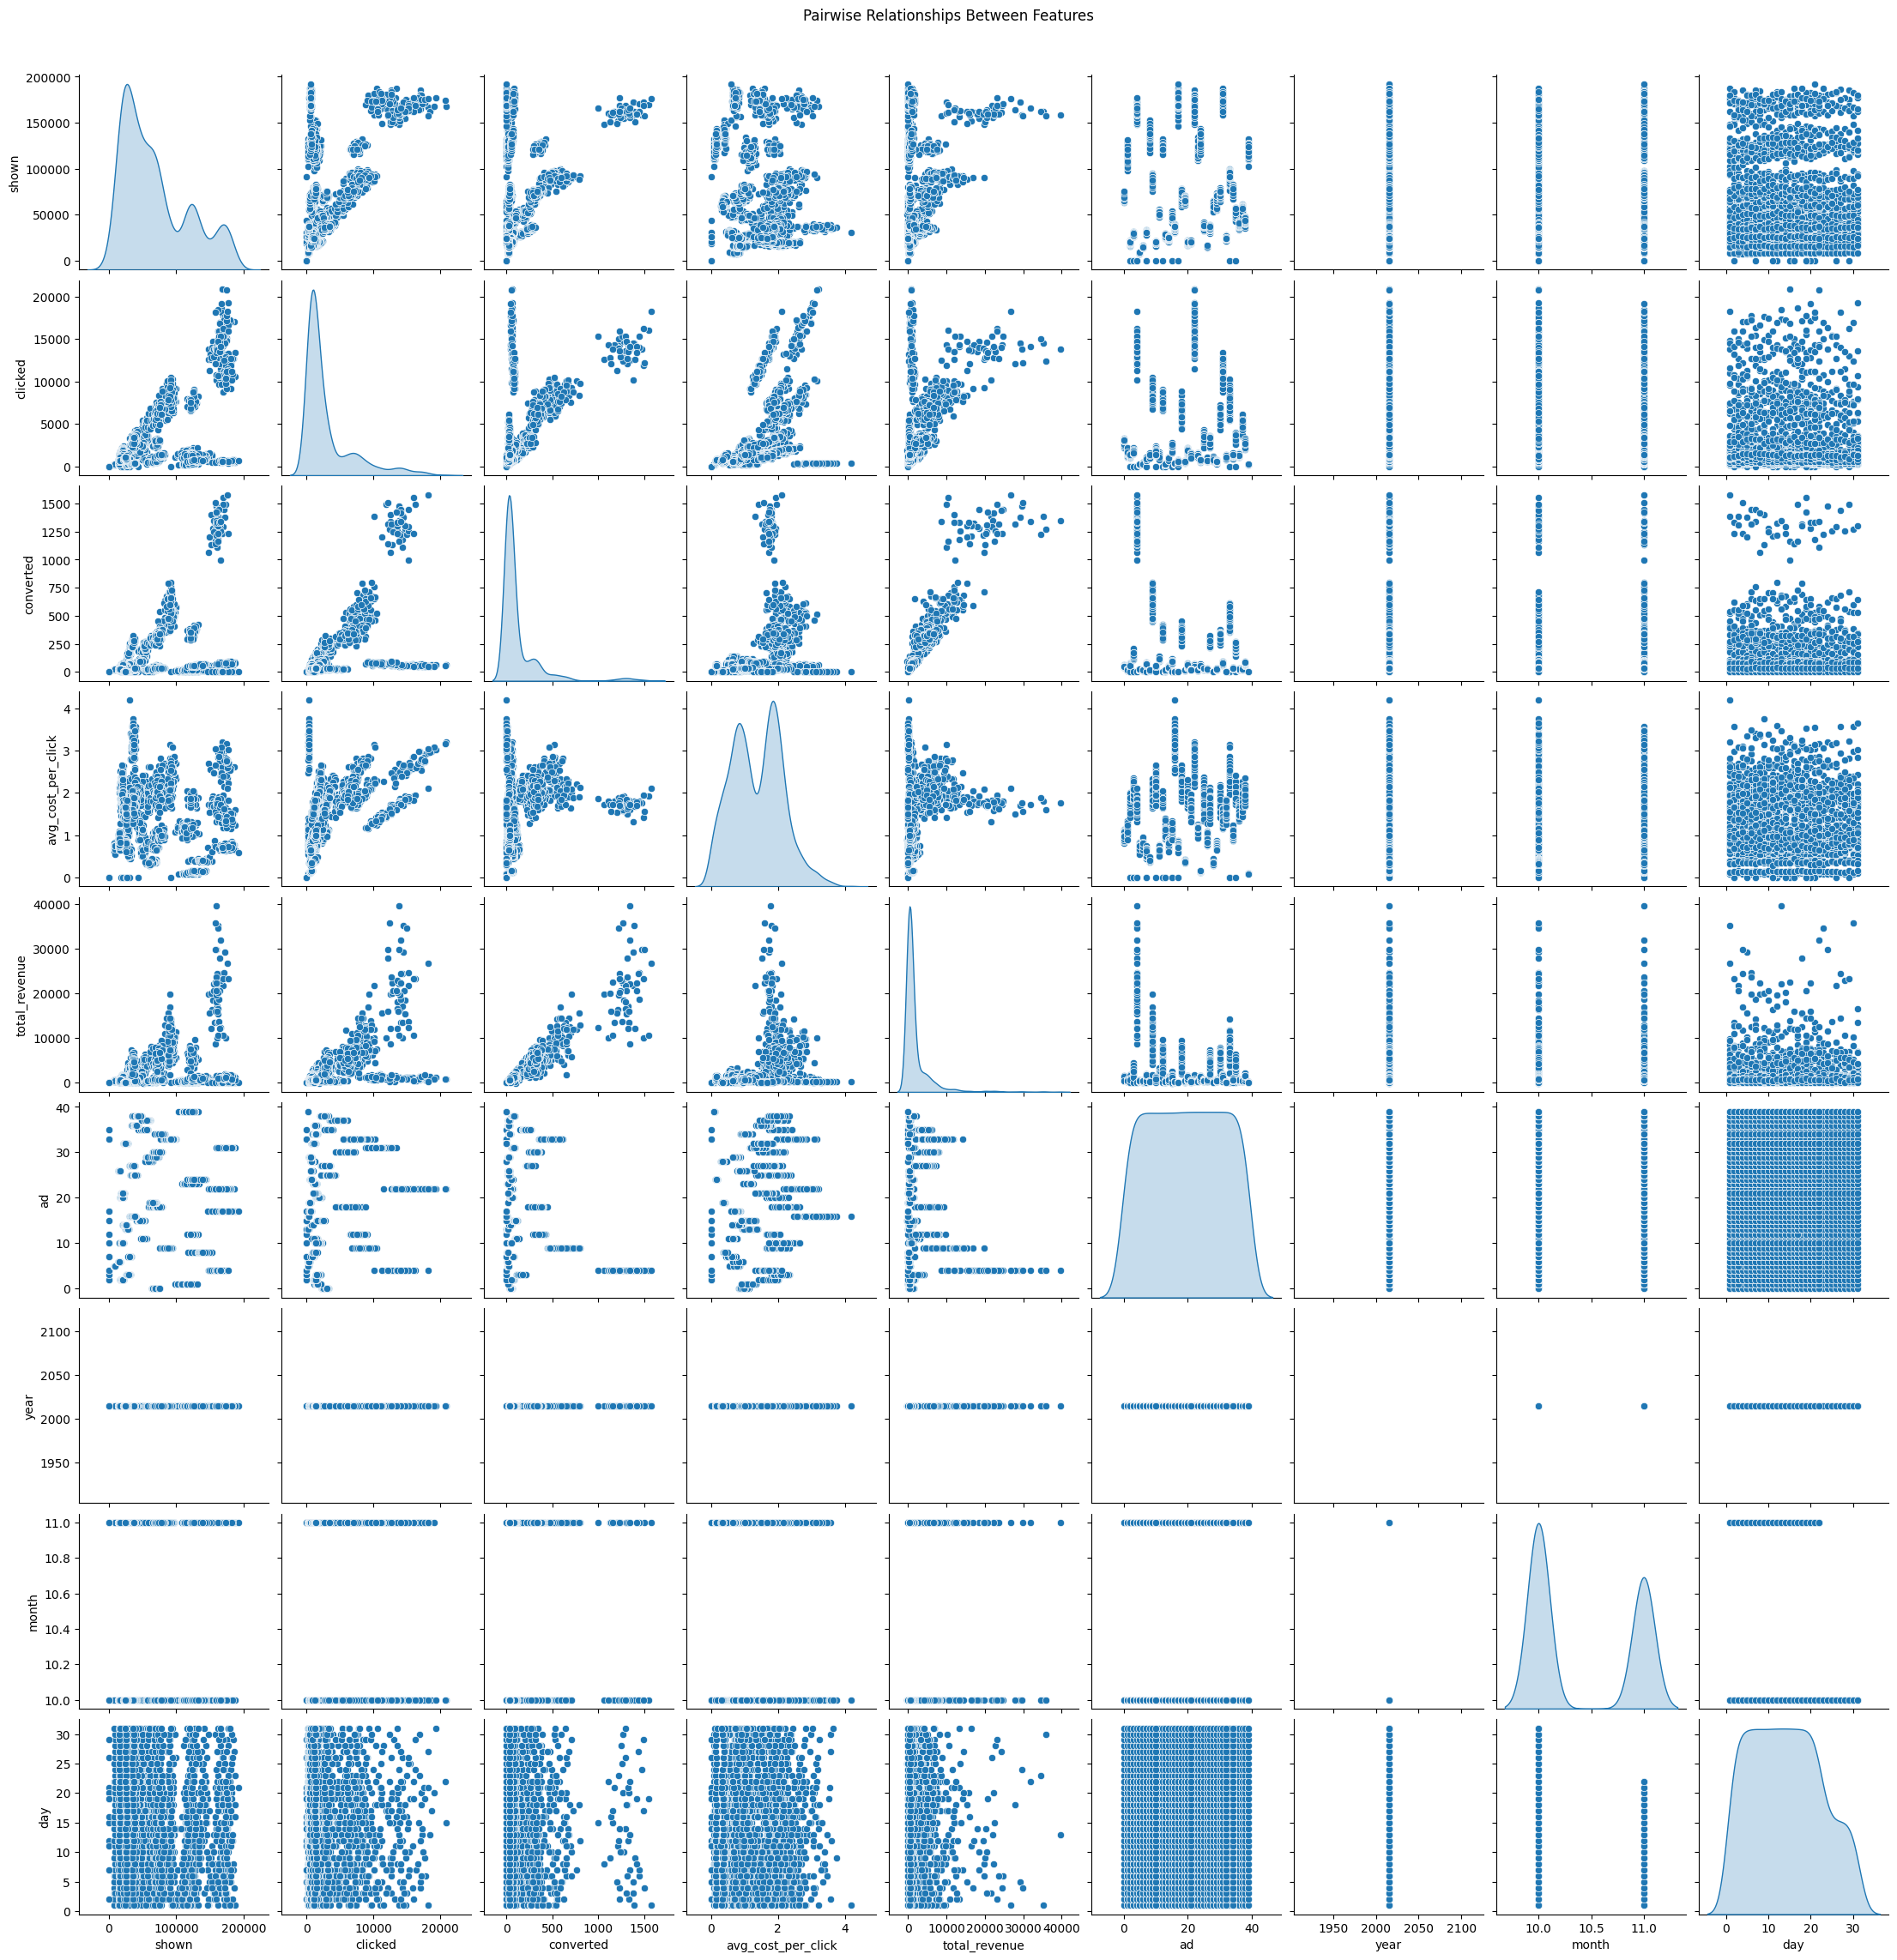

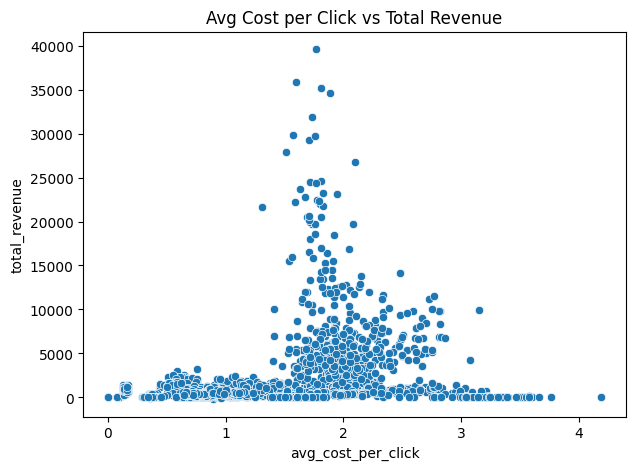

In [5]:
# Basic Statistics
print("\n📈 Data Description:")
print(df.describe())

# Scatterplots (visualize relationships)
sns.pairplot(df, diag_kind='kde')
plt.suptitle("Pairwise Relationships Between Features", y=1.02)
plt.show()

# Example: Relationship with Revenue
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='avg_cost_per_click', y='total_revenue')
plt.title("Avg Cost per Click vs Total Revenue")
plt.show()


In [6]:
# Feature selection
X = df[['shown', 'clicked', 'converted', 'avg_cost_per_click']]
y = df['total_revenue']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for models that need it (like SVR, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
!pip install catboost



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from catboost import CatBoostRegressor


In [9]:
from catboost import CatBoostRegressor

# Initialize model
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100
)

# Train model
cat_model.fit(X_train, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_test)

# Evaluation
mse_cat = mean_squared_error(y_test, y_pred_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print("\n🐱 CatBoost Results:")
print(f"Mean Squared Error: {mse_cat:.2f}")
print(f"R-squared (Accuracy): {r2_cat*100:.2f}%")


0:	learn: 3937.2509474	total: 95.3ms	remaining: 47.6s
100:	learn: 1098.4685233	total: 429ms	remaining: 1.69s
200:	learn: 900.8523079	total: 736ms	remaining: 1.09s
300:	learn: 787.0785814	total: 1.04s	remaining: 689ms
400:	learn: 708.1607781	total: 1.34s	remaining: 331ms
499:	learn: 638.7950819	total: 1.65s	remaining: 0us

🐱 CatBoost Results:
Mean Squared Error: 1971137.28
R-squared (Accuracy): 80.86%


In [10]:
!pip install lightgbm



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
print(np.__version__)


1.26.4


In [12]:
!pip install numpy==1.26.4 --force-reinstall --no-cache-dir



   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
    --------------------------------------- 0.3/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 932.9 kB/s eta 0:00:17
   - -------------------------------------- 0.8/15.8 MB 1.0 MB/s eta 0:00:15
   -- ------------------------------------- 1.0/15.8 MB 1.0 MB/s eta 0:00:15
   -- ------------------------------------- 1.0/15.8 MB 1.0 MB/s eta 0:00:15
   --- ------------------------------------ 1.3/15.8 MB 986.4 kB/s eta 0:00:15
   --- ------------------------------------ 1.6/15.8 MB 998.3 kB/s eta 0:00:15
   ---- ----------------------------------- 1.8/15.8 MB 1.0 MB/s eta 0:00:14
   ----- ---------------------------------- 2.1/15.8 MB 1.0 MB/s eta 0:00:14
   ----- ---------------------------------- 2.4/15.8 MB 1.0 MB/s eta 0:00:14
   ------ --------------------------------- 2.6/15.8 MB 1.1 MB/s eta 0:00:13
   ------- ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from lightgbm import LGBMRegressor

# Initialize LightGBM
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

# Train
lgb_model.fit(X_train, y_train)

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print("\n💡 LightGBM Results:")
print(f"Mean Squared Error: {mse_lgb:.2f}")
print(f"R-squared (Accuracy): {r2_lgb*100:.2f}%")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1016
[LightGBM] [Info] Number of data points in the train set: 1692, number of used features: 4
[LightGBM] [Info] Start training from score 1993.974826

💡 LightGBM Results:
Mean Squared Error: 2329969.76
R-squared (Accuracy): 77.37%


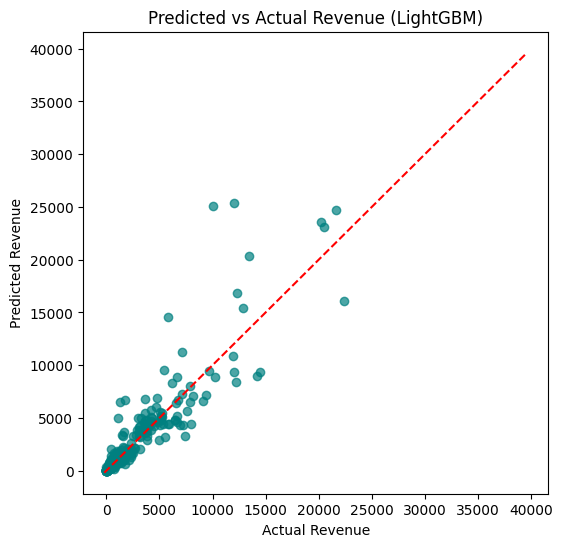

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lgb, alpha=0.7, color='teal')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Predicted vs Actual Revenue (LightGBM)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()


In [15]:
results = pd.DataFrame({
    'Model': ['CatBoost', 'LightGBM'],
    'MSE': [mse_cat, mse_lgb],
    'R² (Accuracy)': [r2_cat, r2_lgb]
})

print("\n📊 Model Comparison Summary:")
print(results)



📊 Model Comparison Summary:
      Model           MSE  R² (Accuracy)
0  CatBoost  1.971137e+06       0.808574
1  LightGBM  2.329970e+06       0.773726


In [16]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Base learners
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize base models
cat_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0)
lgb_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
rf_model = RandomForestRegressor(n_estimators=150, random_state=42)

# Stacking ensemble
hybrid_model = StackingRegressor(
    estimators=[
        ('catboost', cat_model),
        ('lightgbm', lgb_model),
        ('random_forest', rf_model)
    ],
    final_estimator=RidgeCV(),   # Meta-model learns how to weight their outputs
    passthrough=True
)

# Train hybrid model
hybrid_model.fit(X_train, y_train)

# Predict
y_pred_hybrid = hybrid_model.predict(X_test)

# Evaluate
mse_hybrid = mean_squared_error(y_test, y_pred_hybrid)
r2_hybrid = r2_score(y_test, y_pred_hybrid)

print("\n🤖 Hybrid Model (CatBoost + LightGBM + RF + Ridge):")
print(f"Mean Squared Error: {mse_hybrid:.2f}")
print(f"R-squared (Accuracy): {r2_hybrid*100:.2f}%")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1016
[LightGBM] [Info] Number of data points in the train set: 1692, number of used features: 4
[LightGBM] [Info] Start training from score 1993.974826
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1010
[LightGBM] [Info] Number of data points in the train set: 1353, number of used features: 4
[LightGBM] [Info] Start training from score 2016.158090
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1011
[LightGBM] [Info] Number of data points in the train s

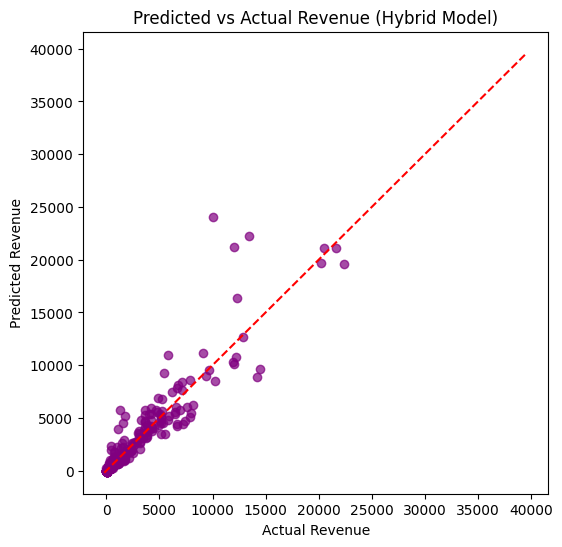

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_hybrid, alpha=0.7, color='purple')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Predicted vs Actual Revenue (Hybrid Model)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()
